# Analiza gora in pohodniških poti (hribi.net)

Podatki izvirajo iz spletne strani hribi.net, ki so shranjeni v dveh datotekah v mapi `podatki`:
- `hribi.csv` - vrhovi (ime, drzava, gorovje, visina, ...)
- `poti.csv` - pohodniske poti (cas hoje, dolzina, zahtevnost, ...)

Vsaka pot je preko `gora_id` povezana z vrhom v hribi.csv.

Pogledali si bomo: koliko je slovenskih/tujih vrhov in poti, kako so poti in vrhovi porazdeljeni po slovenskih gorovjih, ali višina vrha vpliva na število poti, kakšna je zahtevnost/označenost poti, čas in dolžina hoje glede na zahtevnost in primerjava z Naismithovim pravilom, strmina poti in na koncu se porazdelitev višin.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

hribi = pd.read_csv("podatki/hribi.csv", sep=";")
poti = pd.read_csv("podatki/poti.csv", sep=";")

hribi.head()

,id,ime_gore,drzava,gorovje,visina,vrsta,ogledi,stevilo_slik,stevilo_poti,stevilo_gps_sledi,vpisna_knjiga,sirina,dolzina,priljubljenost_pct,mesto
0,1,Triglav,Slovenija,Julijske Alpe,2864.0,"vrh,bivak",1965519,44,29,20,29.0,46.37832,13.83648,100,1
1,2,Škrlatica,Slovenija,Julijske Alpe,2740.0,vrh,905743,24,5,5,3.0,46.43277,13.82114,99,43
2,3,Mali Triglav,Slovenija,Julijske Alpe,2725.0,vrh,540768,4,10,2,18.0,46.37683,13.84315,93,271
3,4,Mangart,"Italija, Slovenija",Julijske Alpe,2679.0,vrh,1080776,26,8,5,11.0,46.43948,13.65457,100,18
4,5,Visoki Rokav,Slovenija,Julijske Alpe,2646.0,vrh,534269,2,2,0,NaN,46.43547,13.82830,93,283


Nekateri stolpci se pri branju CSV-ja preberejo kot besedilo, zato jih pretvorim v števila (zahtevnost,...). Poti, ki imajo čas hoje nad 600 min (10 ur), smo odstranili, saj so to verjetno večdnevne ture ali pa napačno vneseni podatki, ki bi mi pokvarili povprečja.

In [25]:
poti["cas_hoje_min"] = pd.to_numeric(poti["cas_hoje_min"], errors="coerce")
poti["dolzina_km"] = pd.to_numeric(poti["dolzina_km"], errors="coerce")
poti["zahtevnost"] = pd.to_numeric(poti["zahtevnost"], errors="coerce")
poti["oznacena"] = pd.to_numeric(poti["oznacena"], errors="coerce")
poti["visinska_razlika_m"] = pd.to_numeric(poti["visinska_razlika_m"], errors="coerce")
poti["visinska_razlika_po_poti_m"] = pd.to_numeric(poti["visinska_razlika_po_poti_m"], errors="coerce")

hribi["visina"] = pd.to_numeric(hribi["visina"], errors="coerce")
hribi["stevilo_poti"] = pd.to_numeric(hribi["stevilo_poti"], errors="coerce")

poti = poti[poti["cas_hoje_min"] <= 600]

# vzpon je pri nekaterih poteh v drugem stolpcu, zato ju zdruzim
poti["vzpon_m"] = poti["visinska_razlika_po_poti_m"].fillna(poti["visinska_razlika_m"])

# pripnem podatke o gori (drzava, gorovje, visina) k vsaki poti
poti_polno = poti.merge(
    hribi[["id", "drzava", "gorovje", "visina", "stevilo_poti"]],
    left_on="gora_id", right_on="id", suffixes=("", "_gora")
)

poti_slo = poti_polno[poti_polno["drzava"] == "Slovenija"]
poti_polno.head(3)

,gora_id,pot_id,izhodisce,izhodisce_visina_m,sirina,dolzina,cilj,cilj_visina_m,ime_poti,cas_hoje_min,...,oprema_zima,ogledi,stevilo_slik,stevilo_komentarjev,vzpon_m,id,drzava,gorovje,visina,stevilo_poti
0,1,125,Aljažev dom v Vratih,987,46.4128,13.8466,Triglav,2864,Tominškova pot,370,...,"čelada, komplet za samovarovanje, cepin, dereze",398612,61,281,1930.0,1,Slovenija,Julijske Alpe,2864.0,29
1,1,133,Konec ceste na Pokljuki,1312,46.3386,13.9045,Triglav,2864,čez Planiko in Mali Triglav,360,...,"čelada, komplet za samovarovanje, cepin, dereze",298701,109,154,1700.0,1,Slovenija,Julijske Alpe,2864.0,29
2,1,129,Dolina Krma,930,46.3851,13.9071,Triglav,2864,čez Kredarico,375,...,"čelada, komplet za samovarovanje, cepin, dereze",290379,82,97,1985.0,1,Slovenija,Julijske Alpe,2864.0,29


## 1. Slovenija in tujina

Kolikšen delež vrhov in poti je slovenskih in koliko je tujih.

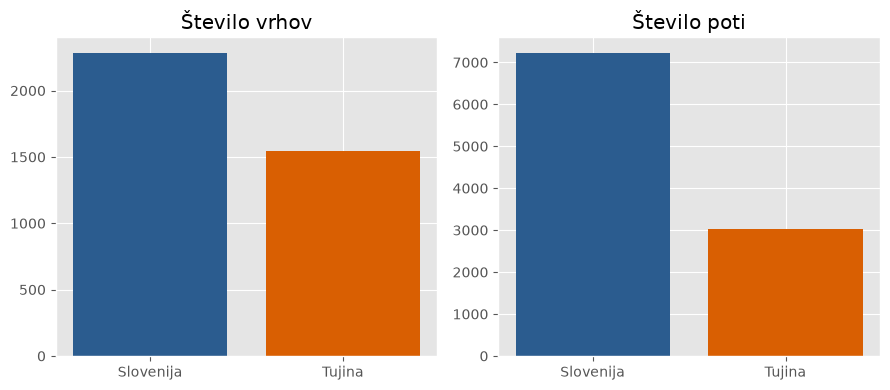

In [26]:
st_hribi_slo = (hribi["drzava"] == "Slovenija").sum()
st_hribi_tuja = len(hribi) - st_hribi_slo

st_poti_slo = (poti_polno["drzava"] == "Slovenija").sum()
st_poti_tuja = len(poti_polno) - st_poti_slo

plt.figure(figsize=(9, 4))

plt.subplot(1, 2, 1)
plt.bar(["Slovenija", "Tujina"], [st_hribi_slo, st_hribi_tuja], color=["#2b5c8f", "#d95f02"])
plt.title("Število vrhov")

plt.subplot(1, 2, 2)
plt.bar(["Slovenija", "Tujina"], [st_poti_slo, st_poti_tuja], color=["#2b5c8f", "#d95f02"])
plt.title("Število poti")

plt.tight_layout()
plt.show()

## 2. Slovenska gorovja

Gorovji Trstelj in Kozjansko imata premalo vrhov, da bi ju smiselno primerjal z ostalimi, zato ju izločimo iz analize.

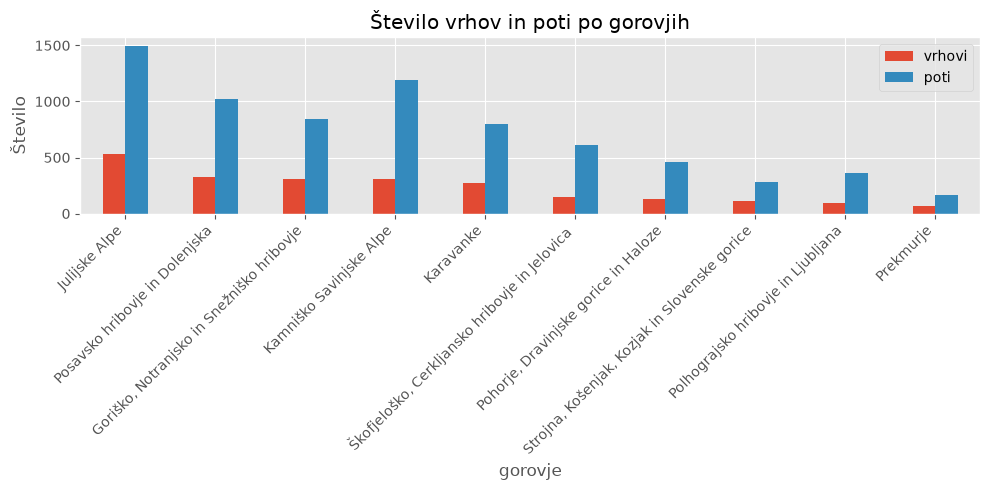

In [27]:
izloci = ["TRSTELJ", "Kozjansko"]

hribi_slo = hribi[(hribi["drzava"] == "Slovenija") & (~hribi["gorovje"].isin(izloci))]
poti_slo_g = poti_slo[~poti_slo["gorovje"].isin(izloci)]

gorovja = pd.DataFrame({
    "vrhovi": hribi_slo["gorovje"].value_counts(),
    "poti": poti_slo_g["gorovje"].value_counts(),
}).fillna(0).sort_values("vrhovi", ascending=False)

gorovja.plot(kind="bar", figsize=(10, 5))
plt.title("Število vrhov in poti po gorovjih")
plt.ylabel("Število")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Zanima nas tudi, katera gorovja imajo v povprečju več poti na en vrh ($\frac{poti}{vrhovi}$).

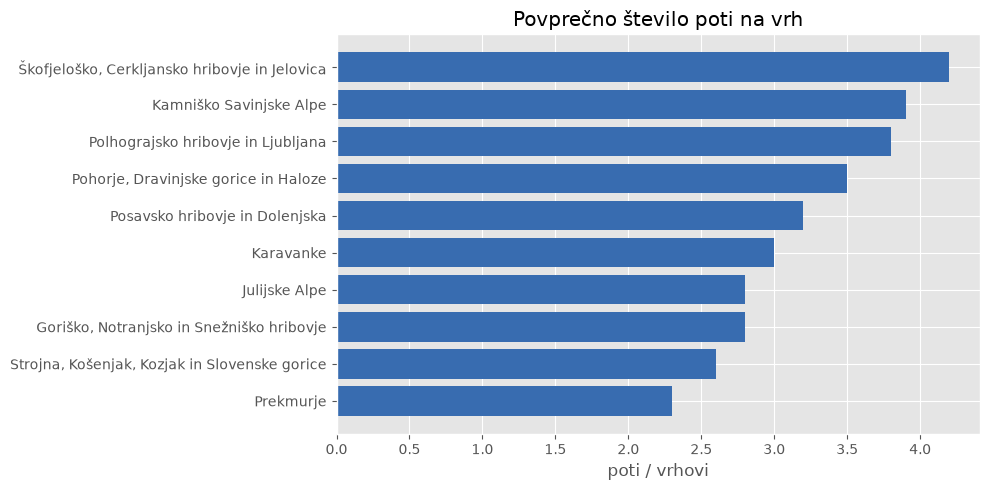

,vrhovi,poti,poti_na_vrh
gorovje,,,
"Škofjeloško, Cerkljansko hribovje in Jelovica",146,613,4.2
Kamniško Savinjske Alpe,304,1193,3.9
Polhograjsko hribovje in Ljubljana,95,362,3.8
"Pohorje, Dravinjske gorice in Haloze",132,458,3.5
Posavsko hribovje in Dolenjska,325,1024,3.2
Karavanke,270,803,3.0
Julijske Alpe,527,1497,2.8
"Goriško, Notranjsko in Snežniško hribovje",305,839,2.8
"Strojna, Košenjak, Kozjak in Slovenske gorice",110,283,2.6


In [28]:
gorovja["poti_na_vrh"] = (gorovja["poti"] / gorovja["vrhovi"]).round(1)
gorovja_sort = gorovja.sort_values("poti_na_vrh", ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(gorovja_sort.index[::-1], gorovja_sort["poti_na_vrh"][::-1], color="#386cb0")
plt.title("Povprečno število poti na vrh")
plt.xlabel("poti / vrhovi")
plt.tight_layout()
plt.show()

gorovja_sort

Še izpis 5 slovenskih vrhov, na katere vodi največ različnih poti.

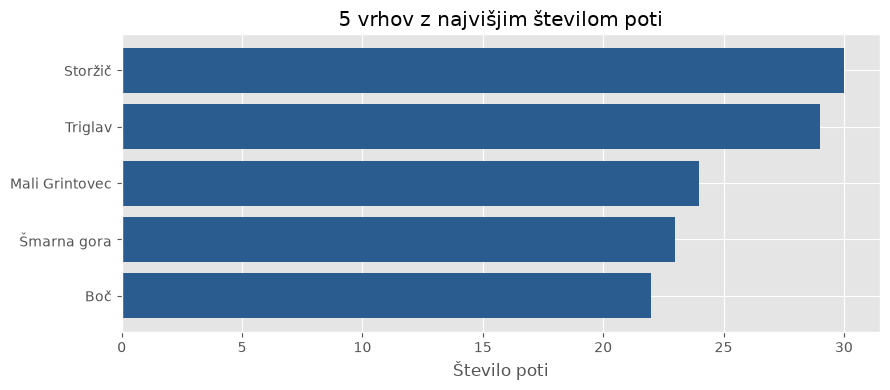

,ime_gore,gorovje,visina,stevilo_poti
49,Storžič,Kamniško Savinjske Alpe,2132.0,30
0,Triglav,Julijske Alpe,2864.0,29
290,Mali Grintovec,Kamniško Savinjske Alpe,1813.0,24
68,Šmarna gora,Polhograjsko hribovje in Ljubljana,669.0,23
470,Boč,Karavanke,978.0,22


In [29]:
top5 = hribi[hribi["drzava"] == "Slovenija"].sort_values("stevilo_poti", ascending=False).head(5)

plt.figure(figsize=(9, 4))
plt.barh(top5["ime_gore"][::-1], top5["stevilo_poti"][::-1], color="#2b5c8f")
plt.title("5 vrhov z najvišjim številom poti")
plt.xlabel("Število poti")
plt.tight_layout()
plt.show()

top5[["ime_gore", "gorovje", "visina", "stevilo_poti"]]

## 3. Višina vrha in število poti

Ali višji vrhovi privabijo več poti? Najprej lahko primerjamo število poti glede na višine vrhov, nato še po zahtevnosti poti.

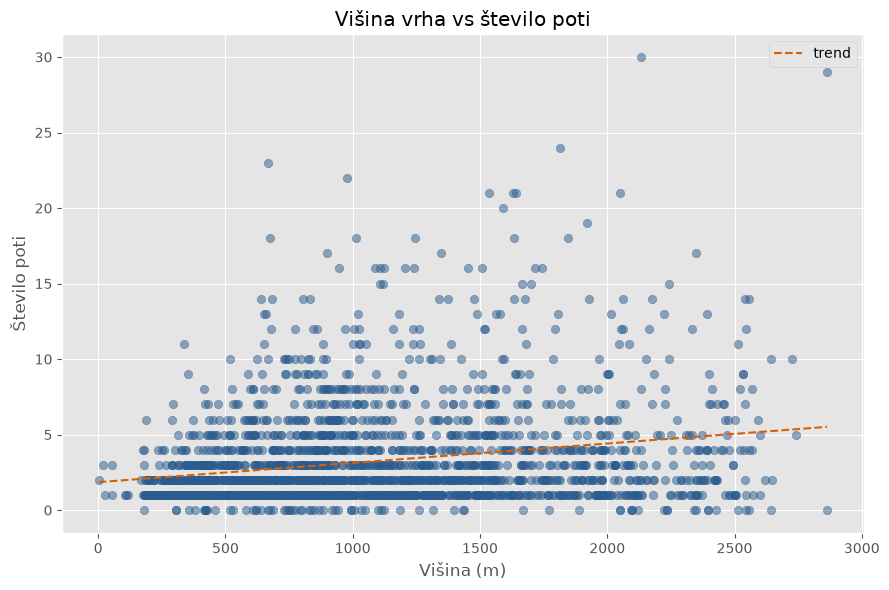

Korelacija: 0.23


In [30]:
hribi_v = hribi[hribi["drzava"] == "Slovenija"].dropna(subset=["visina", "stevilo_poti"])

plt.figure(figsize=(9, 6))
plt.scatter(hribi_v["visina"], hribi_v["stevilo_poti"], alpha=0.5, color="#2b5c8f")

# trend linija
k = np.polyfit(hribi_v["visina"], hribi_v["stevilo_poti"], 1)
x = np.linspace(hribi_v["visina"].min(), hribi_v["visina"].max(), 100)
plt.plot(x, np.poly1d(k)(x), "--", color="#d95f02", label="trend")

plt.title("Višina vrha vs število poti")
plt.xlabel("Višina (m)")
plt.ylabel("Število poti")
plt.legend()
plt.tight_layout()
plt.show()

print("Korelacija:", round(hribi_v["visina"].corr(hribi_v["stevilo_poti"]), 2))

Zaradi nizke korelacije lahko sklepamo, da višina nima velikega vpliva na število poti.

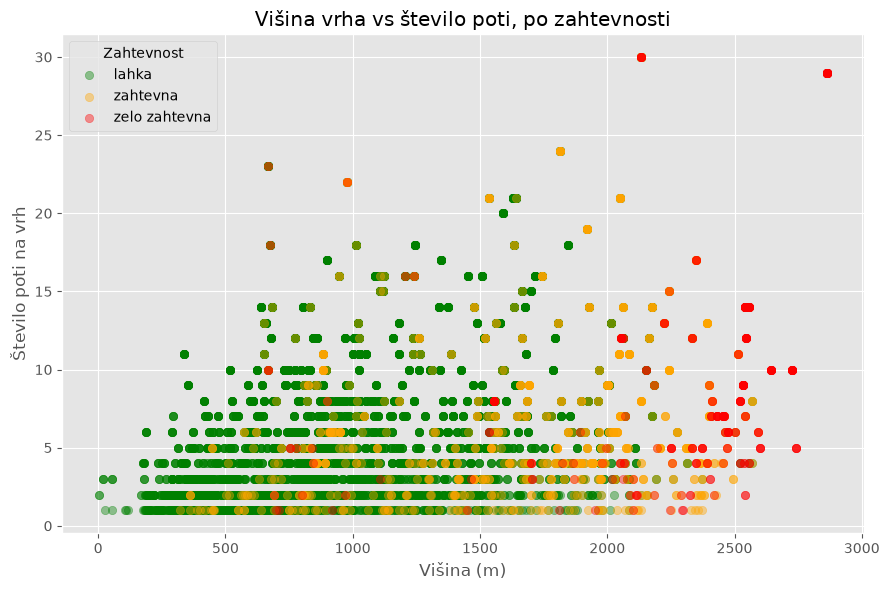

In [31]:
oznake = {1: "lahka", 2: "zahtevna", 3: "zelo zahtevna"}
barve = {1: "green", 2: "orange", 3: "red"}

poti_z = poti_slo.dropna(subset=["visina", "stevilo_poti", "zahtevnost"])
poti_z = poti_z[poti_z["zahtevnost"].isin([1, 2, 3])]

plt.figure(figsize=(9, 6))
for z in [1, 2, 3]:
    del_ = poti_z[poti_z["zahtevnost"] == z]
    plt.scatter(del_["visina"], del_["stevilo_poti"], color=barve[z], label=oznake[z], alpha=0.4)

plt.title("Višina vrha vs število poti, po zahtevnosti")
plt.xlabel("Višina (m)")
plt.ylabel("Število poti na vrh")
plt.legend(title="Zahtevnost")
plt.tight_layout()
plt.show()

## 4. Zahtevnost in označenost poti

S tortnim prikazom, si lahko pogledamo delež poti po zahtevnosti in označenosti.

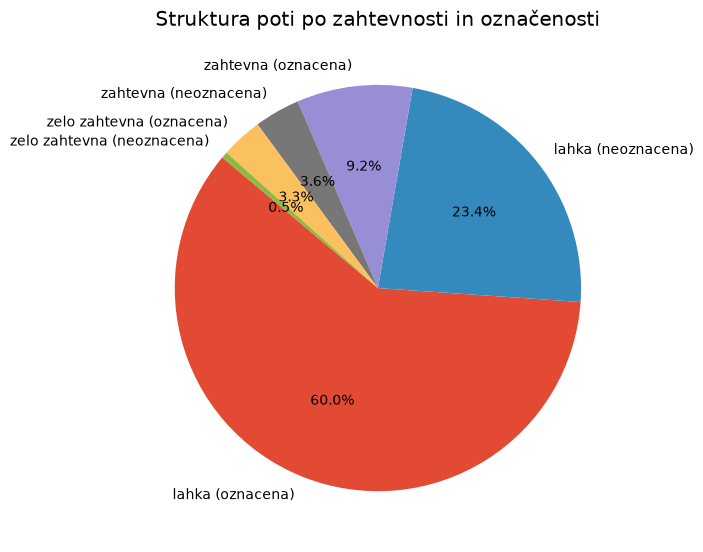

In [32]:
poti_p = poti_slo[poti_slo["zahtevnost"].isin([1, 2, 3])].dropna(subset=["oznacena"])
poti_p = poti_p[poti_p["oznacena"].isin([0, 1])]

oznacenost = {1: "oznacena", 0: "neoznacena"}
poti_p["kombinacija"] = poti_p["zahtevnost"].map(oznake) + " (" + poti_p["oznacena"].map(oznacenost) + ")"

stevilo = poti_p["kombinacija"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(stevilo, labels=stevilo.index, autopct="%1.1f%%", startangle=140)
plt.title("Struktura poti po zahtevnosti in označenosti")
plt.tight_layout()
plt.show()

Lahko vidimo da je večina poti po zahtevnosti lahkih, pri tem pa približno četrtina vseh poti neoznačenih.

## 5. Čas hoje in dolžina poti glede na zahtevnost

Poglejmo si ali zahtevnejše poti res pomenijo daljši caš hoje in večjo skupno prehojeno dolžino.

In [33]:
poti_c = poti_slo[poti_slo["zahtevnost"].isin([1, 2, 3])].dropna(subset=["cas_hoje_min", "dolzina_km"])
poti_c["cas_hoje_h"] = poti_c["cas_hoje_min"] / 60

povp = poti_c.groupby("zahtevnost").agg(
    stevilo=("zahtevnost", "count"),
    cas_h=("cas_hoje_h", "mean"),
    dolzina_km=("dolzina_km", "mean"),
    vzpon_m=("vzpon_m", "mean"),
).round(2)
povp.index = povp.index.map(oznake)
povp

,stevilo,cas_h,dolzina_km,vzpon_m
zahtevnost,,,,
lahka,2972,2.05,5.25,557.11
zahtevna,578,3.78,6.94,1081.91
zelo zahtevna,234,5.28,7.58,1535.50


Tukaj lahko vidimo da zahtevnost vpliva tako na čas in dolžino hoje kot tudi višinsko razliko vzpona.

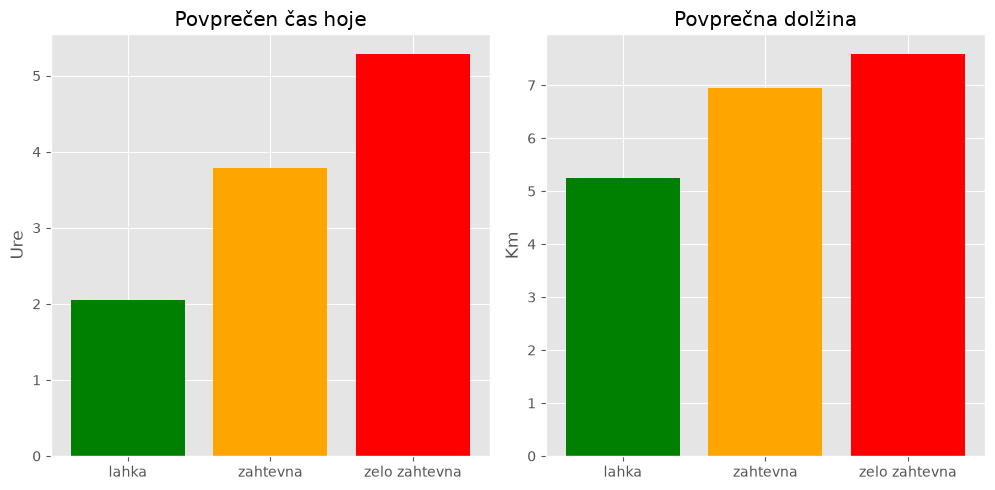

In [34]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.bar(povp.index, povp["cas_h"], color=list(barve.values()))
plt.title("Povprečen čas hoje")
plt.ylabel("Ure")

plt.subplot(1, 3, 2)
plt.bar(povp.index, povp["dolzina_km"], color=list(barve.values()))
plt.title("Povprečna dolžina")
plt.ylabel("Km")

plt.tight_layout()
plt.show()

In [35]:
poti_h = poti_slo[(poti_slo["dolzina_km"] > 0) & (poti_slo["cas_hoje_min"] > 0)]
poti_h = poti_h[poti_h["zahtevnost"].isin([1, 2, 3])]
poti_h["hitrost_kmh"] = poti_h["dolzina_km"] / (poti_h["cas_hoje_min"] / 60)

hitrost = poti_h.groupby("zahtevnost")["hitrost_kmh"].mean().round(1)
hitrost.index = hitrost.index.map(oznake)
print(hitrost)

zahtevnost
lahka            2.6
zahtevna         1.8
zelo zahtevna    1.4
Name: hitrost_kmh, dtype: float64


Pada tudi povprečna hitrost glede na zahtevnost poti.


### Primerjava z Naismithovim pravilom

Naismithovo pravilo je formula za oceno časa hoje: 12 min na prehojen km (dolžina) + 10min na 100m prehojene višinske razlike (vzpon). To primerjamo z dejanskim časom iz hribi.net.

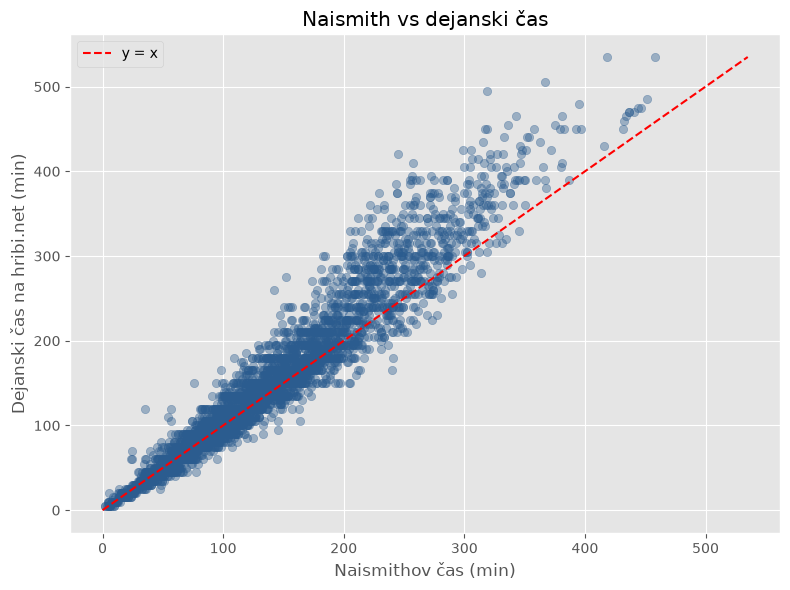

In [36]:
poti_n = poti_slo.dropna(subset=["cas_hoje_min", "dolzina_km", "vzpon_m"])
poti_n = poti_n[(poti_n["dolzina_km"] > 0) & (poti_n["cas_hoje_min"] > 0) & (poti_n["vzpon_m"] >= 0)]
poti_n = poti_n[poti_n["zahtevnost"].isin([1, 2, 3])]

poti_n["naismith_min"] = poti_n["dolzina_km"] * 12 + poti_n["vzpon_m"] / 100 * 10
poti_n["razlika_min"] = poti_n["cas_hoje_min"] - poti_n["naismith_min"]

plt.figure(figsize=(8, 6))
plt.scatter(poti_n["naismith_min"], poti_n["cas_hoje_min"], alpha=0.4, color="#2b5c8f")
m = max(poti_n["naismith_min"].max(), poti_n["cas_hoje_min"].max())
plt.plot([0, m], [0, m], "--", color="red", label="y = x")
plt.xlabel("Naismithov čas (min)")
plt.ylabel("Dejanski čas na hribi.net (min)")
plt.title("Naismith vs dejanski čas")
plt.legend()
plt.tight_layout()
plt.show()

Lahko vidimo da je naismithovo pravilo, natačno pri poti z krajšimi časi, pri daljših poteh pa pravilo oceni čas poti nekoliko prekratko.

## 6. Strmina poti

Zanima me, ali zahtevnost poti dejansko sledi strmini, ali pa nanjo bolj vpliva kaj drugega (npr. ferata).

Korelacija zahtevnost-strmina: 0.49


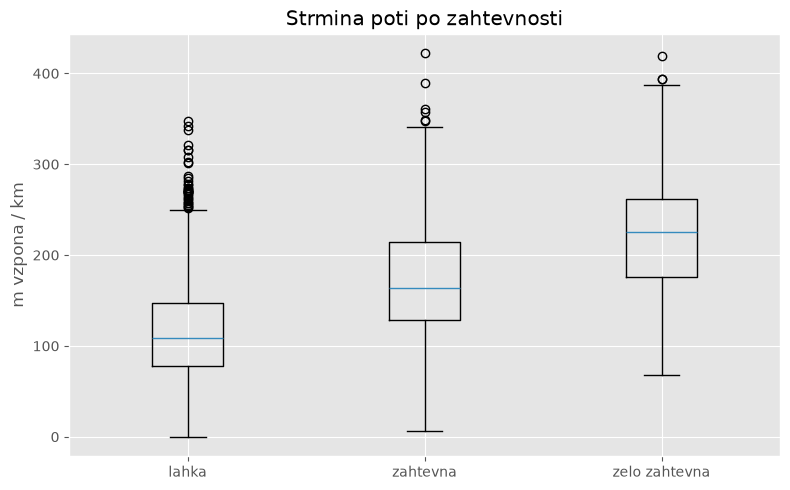

In [37]:
poti_s = poti_slo.dropna(subset=["vzpon_m", "dolzina_km"])
poti_s = poti_s[(poti_s["dolzina_km"] > 0) & (poti_s["vzpon_m"] >= 0)]
poti_s = poti_s[poti_s["zahtevnost"].isin([1, 2, 3])]

poti_s["strmina"] = poti_s["vzpon_m"] / poti_s["dolzina_km"]
poti_s["ima_ferato"] = poti_s["ferata"].notna().astype(int)

print("Korelacija zahtevnost-strmina:", round(poti_s["zahtevnost"].corr(poti_s["strmina"]), 2))

plt.figure(figsize=(8, 5))
skupine = [poti_s.loc[poti_s["zahtevnost"] == z, "strmina"] for z in [1, 2, 3]]
plt.boxplot(skupine, tick_labels=[oznake[z] for z in [1, 2, 3]])
plt.title("Strmina poti po zahtevnosti")
plt.ylabel("m vzpona / km")
plt.tight_layout()
plt.show()

Tudi tukaj lahko vidimo da zahtevnost sledi strmini poti, kar je očitno tudi iz korelacije zahtevnost-strmina.

## 7. Porazdelitev višin slovenskih vrhov

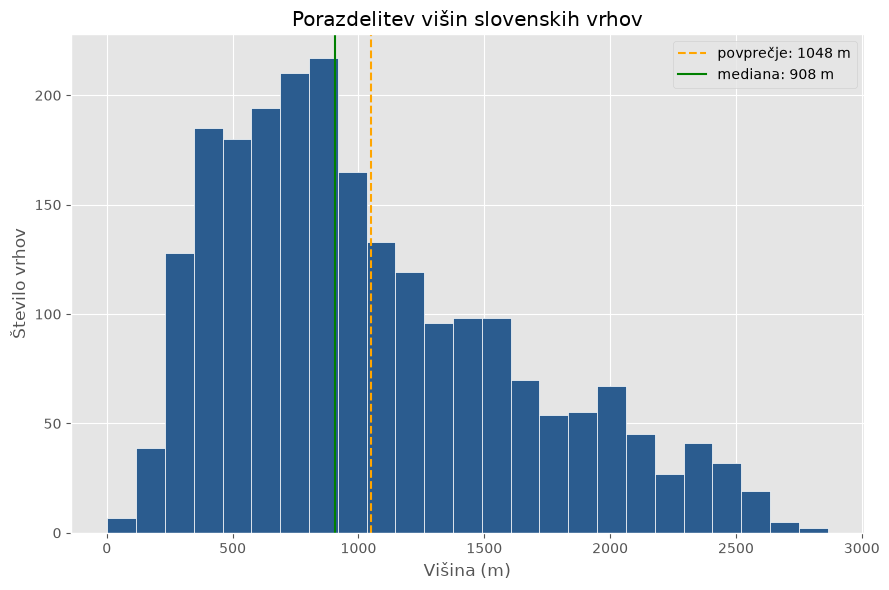

In [41]:
visine = hribi.loc[hribi["drzava"] == "Slovenija", "visina"].dropna()

plt.figure(figsize=(9, 6))
plt.hist(visine, bins=25, color="#2b5c8f", edgecolor="white")
plt.axvline(visine.mean(), color="orange", linestyle="--", label=f"povprečje: {visine.mean():.0f} m")
plt.axvline(visine.median(), color="green", label=f"mediana: {visine.median():.0f} m")
plt.title("Porazdelitev višin slovenskih vrhov")
plt.xlabel("Višina (m)")
plt.ylabel("Število vrhov")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Poti po največjih gorovjih in zahtevnosti

Za 5 gorovij z najvišjim številom poti poglejo kakšna je razdelitev poti po zahtevnosti po gorovjih.

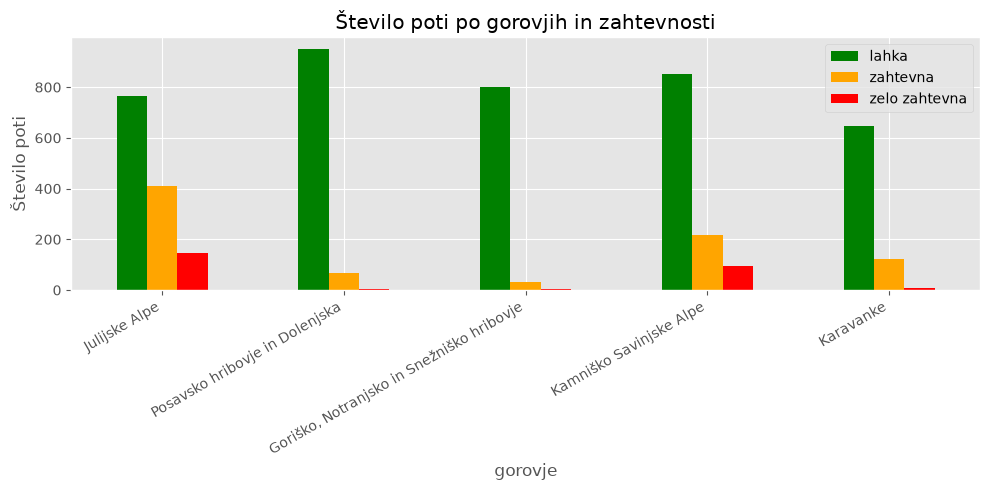

In [39]:
top5_g = hribi_slo["gorovje"].value_counts().head(5).index.tolist()

poti_t5 = poti_slo[poti_slo["gorovje"].isin(top5_g) & poti_slo["zahtevnost"].isin([1, 2, 3])]
pivot = poti_t5.groupby(["gorovje", "zahtevnost"]).size().unstack(fill_value=0).loc[top5_g]
pivot.columns = [oznake[c] for c in pivot.columns]

pivot.plot(kind="bar", figsize=(10, 5), color=list(barve.values()))
plt.title("Število poti po gorovjih in zahtevnosti")
plt.ylabel("Število poti")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Lahko vidimo, da število lahkih poti, je po gorovjih približno enako, ko pride pa do zahtevnih in zelo zahtevnih, pa le te prevladujejo v Julijski in Kamniško Savinjskih Alpah.

## Zaključek

Zgornje in pohodniške poti s spletnega mesta `hribi.net` ponujajo jasen vpogled v značilnosti slovenskega in tujega visokogorja:

* **Slovenski in tuji vrhovi**: Podatki prikazujejo prevlado slovenskih vrhov, kar potrjuje usmerjenost mesta na domače pohodnike.


* **Porazdelitev po gorovjih**: Največ poti imajo območja z najvišjimi vrhovi (Julijske Alpe, Kamniško-Savinjske Alpe, Karavanke).


* **Višina in zahtevnost**: Višji vrhovi imajo več pristopov, ki zahtevajo več časa, daljšo razdaljo ter višjo pripravljenost.


* **Čas in teren**: Primerjava z Naismithovim pravilom potrjuje, da strmina in zahtevnost terena podaljšata čas hoje glede na razdaljo.
